In [3]:
# accuracy per model
# accuracy per question
# accuracy per law

import os
import pandas as pd
import ast

ignore = [".DS_Store"]

questions = [] # {question # : ... , accuracy_on_law_# : ... , accuracy_on_law_# : ...}
laws = [] # {law : ... , accuracy_on_model_# : ... , accuracy_on_model_# : ...}
models = [] # {model : ... , accuracy_on_law_# : ... , accuracy_on_law_# : ...}

reldir = "accuracy_checks"

for subdir, dirs, files in os.walk(reldir):
        for file in files:
            if file in ignore:
                continue
            law = file.split("_(")[0][15:]
            model = file.split("_(")[1].split(").")[0]
            print(f"{file}")
            
            df = pd.read_excel(reldir + "/" + file)
            # print(df.head())
            
            question_dict = {}

            total_accuracy = 0
            
            for question_id, accuracy in zip(df["Question ID"], df["Accuracy"]):
                print(question_id, accuracy)
                question_dict["law"] = law
                question_dict["model"] = model
                if question_id == 4 or question_id == 10:
                    accuracy = ast.literal_eval(accuracy)
                    question_dict[f"{question_id}_average"] = accuracy['average']
                    question_dict[f"{question_id}_addition_penalty"] = accuracy['addition_penalty']
                    question_dict[question_id] = accuracy['total']
                    total_accuracy += int(accuracy['total'])
                else:
                    question_dict[question_id] = accuracy
                    total_accuracy += int(accuracy)
            question_dict["accuracy"] = (total_accuracy / 8) # number of questions
            questions.append(question_dict)

accuracy_check_CT SB-9_(gpt-4o).xlsx
3 0
4 {'average': 0.0, 'addition_penalty': 1.0, 'total': 0}
5 0
6 0
7 0
8 1
10 {'average': 0.25, 'addition_penalty': 0.125, 'total': 0.125}
11 1
accuracy_check_HI HB 173_(llama-3.0-70b-instruct).xlsx
3 0
4 {'average': 0.75, 'addition_penalty': 0.125, 'total': 0.625}
5 0
6 0
7 1
8 1
10 {'average': 0.6380341880341881, 'addition_penalty': 0.2, 'total': 0.4380341880341881}
11 1
accuracy_check_MT MCA 69-3-2001 et seq._(gpt-4o-mini).xlsx
3 0
4 {'average': 1.0, 'addition_penalty': 5.0, 'total': 0}
5 0
6 0
7 0
8 1
10 {'average': 0.5123456790123456, 'addition_penalty': 0.0, 'total': 0.5123456790123456}
11 1
accuracy_check_NJ SB 3723_(gpt-4o).xlsx
3 0
4 {'average': 1.0, 'addition_penalty': 6.0, 'total': 0}
5 0
6 0
7 1
8 1
10 {'average': 0.48912198912198906, 'addition_penalty': 0.09090909090909091, 'total': 0.3982128982128982}
11 1
accuracy_check_NY Public Service Comission Order Establishing New RPS Goal and Resolving Main Tier Issues_(llama-3.0-70b-instruct)

In [4]:
questions_df = pd.DataFrame(questions)
questions_df.to_excel('accuracy_per_sheet.xlsx', index=False)

In [5]:
for col in questions_df.columns.to_list():
    if col == "law" or col == 'model':
        continue
    print(f"{col} : {questions_df.loc[:, col].mean()}")

3 : 0.0
4_average : 0.40178439167918684
4_addition_penalty : 2.4870603517186254
4 : 0.07756817801572695
5 : 0.4568345323741007
6 : 0.0
7 : 0.1618705035971223
8 : 0.8237410071942446
10_average : 0.4354637800716931
10_addition_penalty : 0.6793887670024996
10 : 0.172020892358231
11 : 0.7014388489208633
accuracy : 0.26798561151079137


In [6]:
questions_full = pd.read_excel('../data/Questions.xlsx', sheet_name="Questions") 

In [7]:
questions_mapped = dict(zip(questions_full['ID'], questions_full['Questions']))

In [8]:
shortened_questions = ["CATEGORICAL: List energy sources that receive multifold credit (e.g. doubled, tripled) towards RPS/CES commitment.",
"CATEGORICAL: What are the categories of sales that are excluded and/or exempted from the commitment?",
"NUMERICAL: What is the date at which the commitment passed into law?",
"NUMERICAL: What's the RPS/CES commitment in the policy and what's the year by which the commitment must be met?",
"NUMERICAL: What is the RPS/CES commitment for the year the policy was introduced?",
"NUMERICAL: What's the percentage of the RPS/CES commitment that is voluntary?",
"CATEGORICAL: Identify energy sources that are compliant with RPS criteria.",
"BINARY: Are there any voluntary components of the commitment associated with the farthest date?"]

In [9]:
i = 0
for key in questions_mapped:
    questions_mapped[key] = shortened_questions[i]
    i += 1

In [10]:
questions_mapped

{3: 'CATEGORICAL: List energy sources that receive multifold credit (e.g. doubled, tripled) towards RPS/CES commitment.',
 4: 'CATEGORICAL: What are the categories of sales that are excluded and/or exempted from the commitment?',
 5: 'NUMERICAL: What is the date at which the commitment passed into law?',
 6: "NUMERICAL: What's the RPS/CES commitment in the policy and what's the year by which the commitment must be met?",
 7: 'NUMERICAL: What is the RPS/CES commitment for the year the policy was introduced?',
 8: "NUMERICAL: What's the percentage of the RPS/CES commitment that is voluntary?",
 10: 'CATEGORICAL: Identify energy sources that are compliant with RPS criteria.',
 11: 'BINARY: Are there any voluntary components of the commitment associated with the farthest date?'}

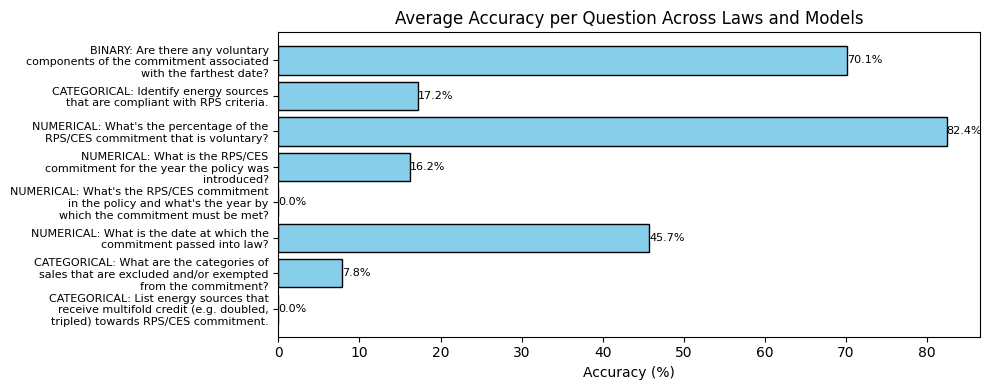

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textwrap

question_descriptions = questions_mapped

wrapped_labels = [textwrap.fill(label, width=40) for label in question_descriptions.values()]

# Extract data for plotting
question_ids = list(question_descriptions.keys())
accuracies = {question: [q.get(question, 0) for q in questions] for question in question_ids}

# Set up the plot
fig, ax = plt.subplots(figsize=(10, len(question_ids) * 0.5))

# Plot the average accuracy for each question
for idx, question in enumerate(question_ids):
    # Multiply accuracy by 100 and round to one decimal place
    avg_accuracy = round(np.mean(accuracies[question]) * 100, 1)
    ax.barh(idx, avg_accuracy, color='skyblue', edgecolor='black')
    ax.text(avg_accuracy, idx, f'{avg_accuracy:.1f}%', va='center', ha='left', color='black', fontsize=8)


# Apply the wrapped labels to the y-axis
ax.set_yticks(range(len(wrapped_labels)))
ax.set_yticklabels(wrapped_labels, fontsize=8)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Average Accuracy per Question Across Laws and Models')

# Display the plot
plt.tight_layout()
plt.show()

In [12]:
questions_df.loc[:, 3].mean()

0.0

In [13]:
laws = {}
models = {}

for law, model, accuracy in zip(questions_df["law"], questions_df["model"], questions_df["accuracy"]):
    if law not in laws:
        tmp = questions_df.loc[questions_df['law'] == law]['accuracy']
        laws[law] = sum(tmp) / len(tmp.index)
    if model not in models:
        tmp = questions_df.loc[questions_df['model'] == model]['accuracy']
        models[model] = sum(tmp) / len(tmp.index)

In [14]:
models_df = pd.DataFrame(models.items(), columns=['model', 'accuracy'])
models_df.to_excel('accuracy_per_model.xlsx', index=False)

laws_df = pd.DataFrame(laws.items(), columns=['law', 'accuracy'])
laws_df.to_excel('accuracy_per_law.xlsx', index=False)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def show_graph(data, title):
    # Separate keys and values
    models = list(data.keys())
    values = list(data.values())

    # Generate a unique color for each bar and shuffle the color order
    cmap = plt.cm.get_cmap('tab20', len(models))  # Larger colormap
    colors = cmap(np.linspace(0, 1, len(models)))  # Get evenly spaced colors from the colormap
    np.random.shuffle(colors)  # Shuffle the colors to avoid similar ones next to each other

    # Adjust figure size based on the number of bars
    plt.figure(figsize=(max(10, len(models) * 0.5), 6))  # Dynamic width based on number of bars
    
    # Create a horizontal bar plot for better label visibility with spacing
    bars = plt.barh(models, values, color=colors, height=0.6)  # `height` controls the bar thickness, making them more spaced out

    # Add value labels next to each bar
    for bar, value in zip(bars, values):
        value_rounded = round(value * 100, 1)  # Multiply by 100 and round to one decimal place
        plt.text(value, bar.get_y() + bar.get_height() / 2, f'{value_rounded}%', va='center', ha='left', fontsize=8, color='black')
        
    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Model')
    plt.title(title)
    
    # Adjust layout and tick label size
    plt.yticks(np.arange(len(models)), models, fontsize=8)  # Ensures even spacing and clear labeling
    plt.tight_layout()

    # Show the plot
    plt.show()


/scratch/local/52672394/ipykernel_602668/109545499.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(models))  # Larger colormap


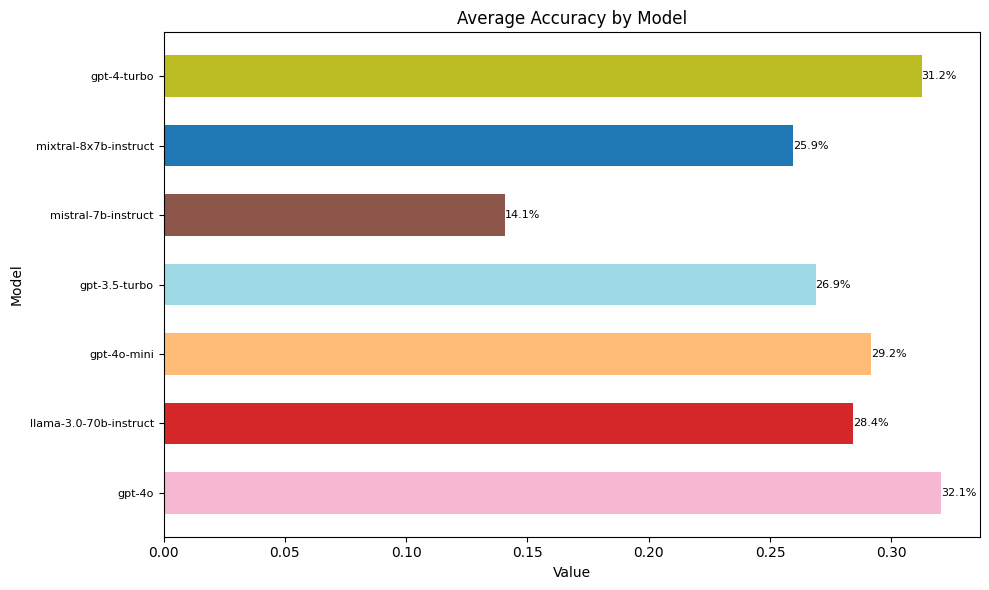

In [17]:
show_graph(models, "Average Accuracy by Model")

In [18]:
models

{'gpt-4o': 0.32051282051282054,
 'llama-3.0-70b-instruct': 0.284375,
 'gpt-4o-mini': 0.2916666666666667,
 'gpt-3.5-turbo': 0.26875,
 'mistral-7b-instruct': 0.140625,
 'mixtral-8x7b-instruct': 0.259375,
 'gpt-4-turbo': 0.3125}

/scratch/local/52672394/ipykernel_602668/109545499.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(models))  # Larger colormap


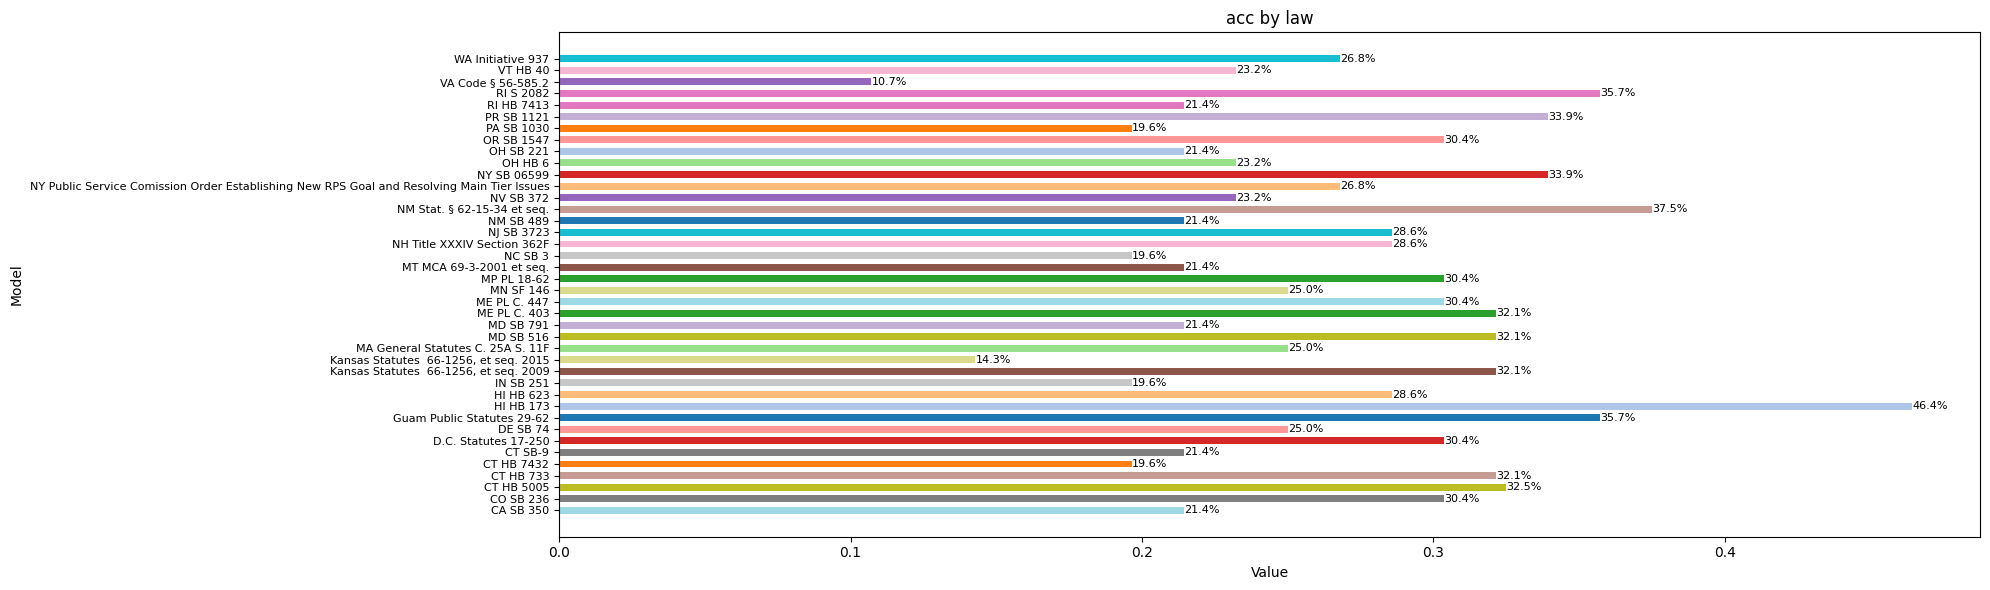

In [19]:
sorted_laws = list(laws.keys())
sorted_laws.sort()

sorted_laws = {i: laws[i] for i in sorted_laws}

show_graph(sorted_laws, "acc by law")

In [20]:
laws

{'CT SB-9': 0.21428571428571427,
 'HI HB 173': 0.4642857142857143,
 'MT MCA 69-3-2001 et seq.': 0.21428571428571427,
 'NJ SB 3723': 0.2857142857142857,
 'NY Public Service Comission Order Establishing New RPS Goal and Resolving Main Tier Issues': 0.26785714285714285,
 'HI HB 623': 0.2857142857142857,
 'VT HB 40': 0.23214285714285715,
 'NM Stat. § 62-15-34 et seq.': 0.375,
 'CT HB 7432': 0.19642857142857142,
 'IN SB 251': 0.19642857142857142,
 'MD SB 516': 0.32142857142857145,
 'RI S 2082': 0.35714285714285715,
 'RI HB 7413': 0.21428571428571427,
 'OH HB 6': 0.23214285714285715,
 'Kansas Statutes  66-1256, et seq. 2015': 0.14285714285714285,
 'OR SB 1547': 0.30357142857142855,
 'NC SB 3': 0.19642857142857142,
 'PR SB 1121': 0.3392857142857143,
 'VA Code § 56-585.2': 0.10714285714285714,
 'NM SB 489': 0.21428571428571427,
 'Kansas Statutes  66-1256, et seq. 2009': 0.32142857142857145,
 'NV SB 372': 0.23214285714285715,
 'CT HB 5005': 0.325,
 'OH SB 221': 0.21428571428571427,
 'MN SF 146'